# Timeseries

in this model, we will learn and apply the various timeseries models

**Homework 1 – ARIMA / GARCH on Apple (AAPL)**

Series: Apple daily closing price, 30 Jun 2010 – 30 Sep 2026 (Yahoo Finance). Real data, not generated.

Plan: visualize → trend and seasonality → stationarity → differencing → lag selection → estimation → diagnostics → GARCH → forecast.

In [1]:
!pip install pmdarima
!pip install pymannkendall

# 1. lets collect the timeseires data

In [2]:
'''Import the Yahooo finance library and pandas'''

import yfinance as yf
import pandas as pd



# Define ticker symbol for Apple
ticker = "AAPL"

# Create a Ticker object
aapl = yf.Ticker(ticker)

'''Interval: daily data'''
data_aapl = aapl.history(start="2010-06-30", end="2026-10-01", interval="1d")

# Print the first few rows
print(data_aapl.head())

                               Open      High       Low     Close      Volume  \
Date                                                                            
2010-06-30 00:00:00-04:00  7.678100  7.715787  7.477707  7.523169   739452000   
2010-07-01 00:00:00-04:00  7.606018  7.620974  7.274620  7.431944  1022896000   
2010-07-02 00:00:00-04:00  7.492061  7.505223  7.274020  7.385883   693842800   
2010-07-06 00:00:00-04:00  7.507316  7.561153  7.362554  7.436431   615235600   
2010-07-07 00:00:00-04:00  7.492064  7.739717  7.469932  7.736725   654556000   

                           Dividends  Stock Splits  
Date                                                
2010-06-30 00:00:00-04:00        0.0           0.0  
2010-07-01 00:00:00-04:00        0.0           0.0  
2010-07-02 00:00:00-04:00        0.0           0.0  
2010-07-06 00:00:00-04:00        0.0           0.0  
2010-07-07 00:00:00-04:00        0.0           0.0  


In [3]:
# Extract only the closing price column
close_prices_aapl = data_aapl["Close"]

# If you want, convert to a DataFrame with date as a column
aapl = pd.DataFrame({"Date": close_prices_aapl.index, "Close": close_prices_aapl.values})
aapl.reset_index(drop=True, inplace=True)

print(aapl.tail())

                          Date       Close
4083 2026-09-24 00:00:00-04:00  335.920013
4084 2026-09-25 00:00:00-04:00  341.070007
4085 2026-09-28 00:00:00-04:00  338.399994
4086 2026-09-29 00:00:00-04:00  329.399994
4087 2026-09-30 00:00:00-04:00  333.019989


In [4]:
aapl.to_csv("apple_stock.csv", index=False)

Data downloaded with `yfinance`, only the `Close` column is kept and saved to `apple_stock.csv` (the same file is used in the ML notebook). Prices are adjusted for the stock splits in 2014 (7:1) and 2020 (4:1) and for dividends, so there are no artificial jumps.

# 2. Analysing the Apple Share price and Predictions

# A. Step 1: Load the data and visulize 

In [5]:
'''===========================STEP 1.1============================'''
import pandas as pd
df = pd.read_csv("apple_stock.csv")


In [6]:
df.shape

(4088, 2)

In [7]:
df['Date'].min()

'2010-06-30 00:00:00-04:00'

In [8]:
df['Date'].max()

'2026-09-30 00:00:00-04:00'

In [9]:
df.describe()

,Close
count,4088.000000
mean,89.114944
std,85.538435
min,7.176218
25%,20.937644
50%,42.205645
75%,154.137394
max,341.070007


4,088 trading days. The price goes from about 7 USD to 341 USD (mean 89 USD, median 42 USD). The range is very big, so the size of daily moves in USD will also be very different between 2010 and 2026.

In [10]:
df['Date']

0       2010-06-30 00:00:00-04:00
1       2010-07-01 00:00:00-04:00
2       2010-07-02 00:00:00-04:00
3       2010-07-06 00:00:00-04:00
4       2010-07-07 00:00:00-04:00
                  ...            
4083    2026-09-24 00:00:00-04:00
4084    2026-09-25 00:00:00-04:00
4085    2026-09-28 00:00:00-04:00
4086    2026-09-29 00:00:00-04:00
4087    2026-09-30 00:00:00-04:00
Name: Date, Length: 4088, dtype: object

In [11]:
df['Date']

0       2010-06-30 00:00:00-04:00
1       2010-07-01 00:00:00-04:00
2       2010-07-02 00:00:00-04:00
3       2010-07-06 00:00:00-04:00
4       2010-07-07 00:00:00-04:00
                  ...            
4083    2026-09-24 00:00:00-04:00
4084    2026-09-25 00:00:00-04:00
4085    2026-09-28 00:00:00-04:00
4086    2026-09-29 00:00:00-04:00
4087    2026-09-30 00:00:00-04:00
Name: Date, Length: 4088, dtype: object

In [12]:
df['Date'] = pd.to_datetime(df['Date'], utc=True)


In [13]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['Close'],
    mode='lines',
    line=dict(color='blue')
))

fig.update_layout(
    title='Apple Daily Closing Price (2010-2026)',
    xaxis_title='Date',
    yaxis_title='Stock Price (USD)',
    hovermode='x unified',
    template='plotly_white',
    showlegend=False
)

fig.show()

In [14]:
'''===========================STEP 1.2 ============================'''

import plotly.graph_objects as go

# Convert the date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Add moving averages
df['MA30'] = df['Close'].rolling(window=30).mean()
df['MA90'] = df['Close'].rolling(window=90).mean()

# Create interactive line chart
fig = go.Figure()

# Daily closing price
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['Close'],
    mode='lines',
    name='Daily Close',
    line=dict(color='blue')
))

# 30-day moving average
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['MA30'],
    mode='lines',
    name='30-Day MA',
    line=dict(color='orange', dash='dash')
))

# 90-day moving average
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['MA90'],
    mode='lines',
    name='90-Day MA',
    line=dict(color='green', dash='dot')
))

# Layout customization
fig.update_layout(
    title='Apple Stock Prices (2010-2026)',
    xaxis_title='Date',
    yaxis_title='Stock Price (USD)',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(x=0, y=1.1, orientation='h')
)

fig.show()

**Visualization:** strong upward trend, much faster after 2019. There are clear drops (e.g. 2020, 2022, early 2025), but no regular repeating pattern. The moves get bigger when the price is higher. The 30- and 90-day moving averages follow the trend and smooth the noise.

# Step 2: Analyzing the trends in data

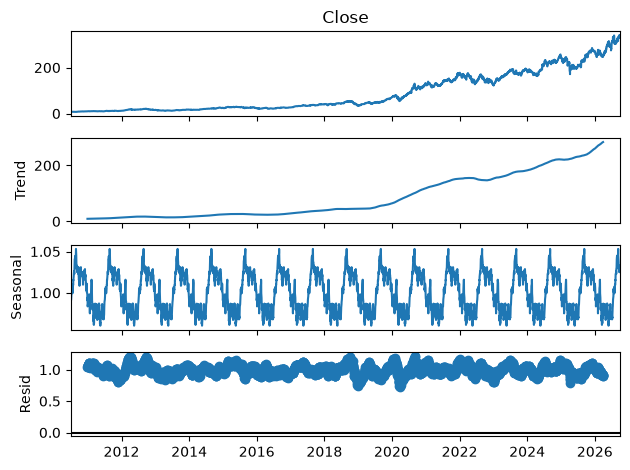

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Set date as index
df_ts = df.set_index('Date')

# Decompose (daily frequency)
result = seasonal_decompose(df_ts['Close'], model='multiplicative', period=252)

# Plot
result.plot()
plt.show()


**Decomposition** (multiplicative, period = 252 trading days = 1 year): the trend is the main part of the series. The seasonal part is small (about ±5%), so seasonality is weak. The residuals are not the same over time – some periods are more volatile.

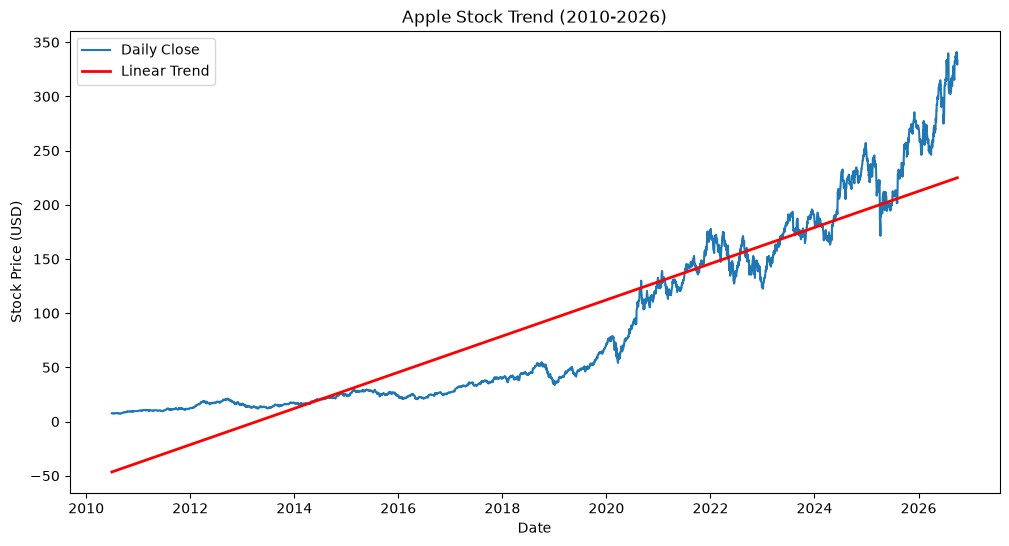

In [16]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Convert dates to ordinal numbers for regression
X = df['Date'].map(pd.Timestamp.toordinal).values.reshape(-1,1)
y = df['Close'].values

model = LinearRegression()
model.fit(X, y)
trend = model.predict(X)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(df['Date'], y, label='Daily Close')
plt.plot(df['Date'], trend, color='red', linewidth=2, label='Linear Trend')
plt.title('Apple Stock Trend (2010-2026)')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()


A straight line does not fit well: at the start it is far below the price, in about 2014–2020 it is above the price, and in the last years it is below again. The growth is faster than linear.

In [17]:
import pymannkendall as mk

trend_test = mk.original_test(df['Close'])
print(trend_test)

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(87.51392548376974), Tau=np.float64(0.9128856854606056), s=np.float64(7626090.0), var_s=np.float64(7593629596.0), slope=np.float64(0.060464522667175745), intercept=np.float64(-81.35360746282969))


**Mann-Kendall test:** trend = increasing, p = 0.0, Tau = 0.91. There is a strong and significant upward trend, so the price is not stationary in mean.

In [18]:
import plotly.graph_objects as go
import pandas as pd
from sklearn.linear_model import LinearRegression

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

# Prepare data for linear trend
X = df['Date'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
y = df['Close'].values

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Calculate trend values
trend = model.predict(X)

# Create figure
fig = go.Figure()

# Daily closing price
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['Close'],
    mode='lines',
    name='Daily Close',
    line=dict(color='blue')
))

# 30-day moving average
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['MA30'],
    mode='lines',
    name='30-Day MA',
    line=dict(color='orange', dash='dash')
))

# 90-day moving average
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['MA90'],
    mode='lines',
    name='90-Day MA',
    line=dict(color='green', dash='dot')
))

# Linear regression trend line
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=trend,
    mode='lines',
    name='Linear Trend',
    line=dict(color='red', width=3)
))

# Mann-Kendall annotation
fig.add_annotation(
    x=df['Date'].iloc[len(df) // 2],
    y=df['Close'].max(),
    text='Mann-Kendall Test: Increasing Trend ✓',
    showarrow=False,
    font=dict(size=14, color='red')
)

# Layout
fig.update_layout(
    title='Apple Stock Prices with Moving Averages & Trend (2010-2026)',
    xaxis_title='Date',
    yaxis_title='Stock Price (USD)',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(x=0, y=1.1, orientation='h')
)

fig.show()

# Step 3: Detrending the data 

In [19]:
'''Detrending using differening'''

df['Close_diff'] = df['Close'].diff()  # simple daily difference

In [20]:
import plotly.graph_objects as go

# Drop the first NaN from differencing
df_diff = df['Close_diff'].dropna()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['Date'].iloc[1:],
    y=df_diff,
    mode='lines',
    name='Daily Difference',
    line=dict(color='purple')
))

fig.update_layout(
    title='Apple Daily Price Changes (Differenced)',
    xaxis_title='Date',
    yaxis_title='Price Change (USD)',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

After the first difference the trend is gone and the series moves around 0. But the size of the changes grows a lot over time (small before 2018, much bigger after 2020). The variance is not constant – we will test this later (ARCH effects).

# Step 4: Staitionarity of data

In [21]:
from statsmodels.tsa.stattools import adfuller

# Drop NaN from differencing
df_diff = df['Close'].dropna()

# Perform ADF test
adf_result = adfuller(df_diff)

print("ADF Statistic: {:.4f}".format(adf_result[0]))
print("p-value: {:.4f}".format(adf_result[1]))
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

ADF Statistic: 2.1412
p-value: 0.9988
Critical Values:
   1%: -3.4320
   5%: -2.8623
   10%: -2.5671


**ADF on price:** statistic 2.14, p = 0.9988 > 0.05. We cannot reject the unit root – the price is **non-stationary**.

In [22]:
from statsmodels.tsa.stattools import adfuller

# Drop NaN from differencing
df_diff = df['Close_diff'].dropna()

# Perform ADF test
adf_result = adfuller(df_diff)

print("ADF Statistic: {:.4f}".format(adf_result[0]))
print("p-value: {:.4f}".format(adf_result[1]))
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")


ADF Statistic: -12.8714
p-value: 0.0000
Critical Values:
   1%: -3.4320
   5%: -2.8623
   10%: -2.5671


**ADF on first difference:** statistic −12.87, p = 0.0000 < 0.05 – the differenced series is **stationary**. One difference is enough, so **d = 1**.

# Step 5: lags Selections

In [23]:
import pmdarima as pm
import pandas as pd

# Use ORIGINAL series (not differenced)
ts = df['Close'].dropna()

criteria = ['aic', 'bic', 'hqic', 'aicc']
best_orders = {}

for crit in criteria:
    model = pm.auto_arima(
        ts,
        start_p=0, max_p=10,
        start_q=0, max_q=10,
        d=None,            # Let auto_arima determine differencing
        max_d=2,           # Maximum differencing order
        seasonal=False,
        information_criterion=crit,
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        trace=False        # Set to True if you want to see the search process
    )
    best_orders[crit.upper()] = model.order

# Convert to DataFrame
best_orders_df = pd.DataFrame(best_orders).T
best_orders_df.columns = ['p', 'd', 'q']

print(best_orders_df)

       p  d  q
AIC   10  2  0
BIC   10  2  0
HQIC  10  2  0
AICC  10  2  0


`auto_arima` on the price chooses (10, 2, 0) with all criteria. This does not agree with the ADF test, which shows that d = 1 is enough – d = 2 would over-difference the series. So we do not use this result and continue with the differenced series.

In [24]:
import pmdarima as pm
import pandas as pd

# Stationary series
ts = df['Close_diff'].dropna()

# Criteria list
criteria = ['aic', 'bic', 'hqic', 'aicc']
best_orders = {}

for crit in criteria:
    model = pm.auto_arima(
        ts,
        start_p=0, max_p=10,
        start_q=0, max_q=10,
        d=0,               # already differenced
        seasonal=False,    # ARMA
        information_criterion=crit,
        stepwise=True,     # fast stepwise search
        suppress_warnings=True,
        error_action='ignore'
    )
    best_orders[crit.upper()] = model.order  # tuple (p,d,q)

# Convert to DataFrame with separate columns
best_orders_df = pd.DataFrame(best_orders).T  # transpose
best_orders_df.columns = ['p','d','q']

print(best_orders_df)


      p  d  q
AIC   1  0  0
BIC   0  0  0
HQIC  0  0  0
AICC  1  0  0


On the differenced series AIC and AICc choose **AR(1)**, BIC and HQIC choose **(0, 0, 0)** – white noise. The series has very little memory. We compare both models below.

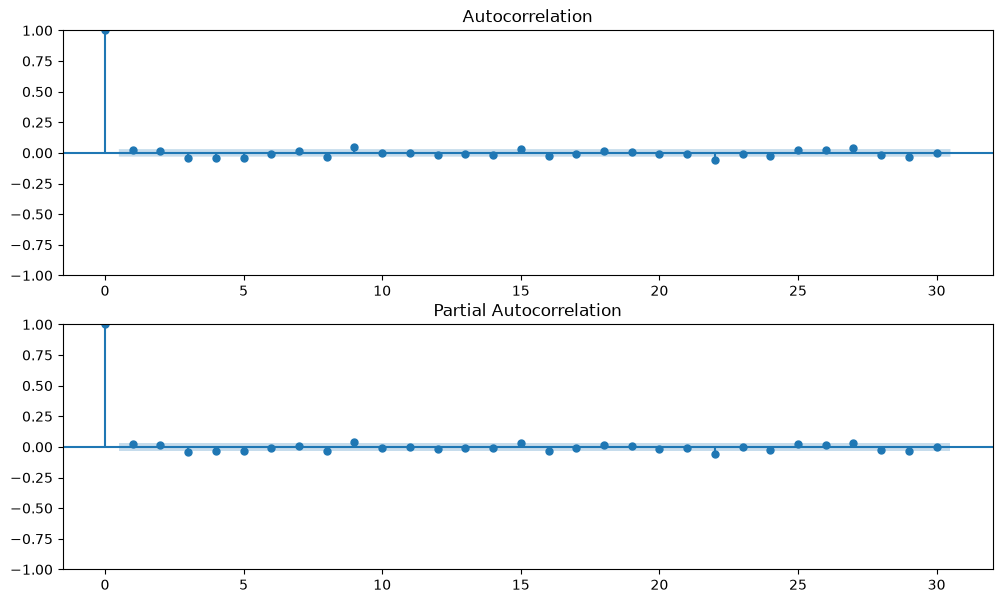

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(df['Close_diff'].dropna(), lags=30, ax=ax[0])
plot_pacf(df['Close_diff'].dropna(), lags=30, ax=ax[1])
plt.show()

**ACF / PACF of the differences:** most bars are inside the confidence band, there are only small spikes (below 0.06) at a few lags, e.g. 3–5, 9 and 22. This agrees with `auto_arima`: a very low order (AR(1) or white noise).

# Step 8: Fitting the Model

# Original Model-

In [26]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# Stationary series
ts = df['Close_diff'].dropna()

# Fit ARMA/ARIMA model (ARIMA(1,0,0))
model = sm.tsa.ARIMA(ts, order=(1,0,0))
result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:             Close_diff   No. Observations:                 4087
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -8879.191
Date:                Sun, 04 Oct 2026   AIC                          17764.381
Time:                        20:56:44   BIC                          17783.328
Sample:                             0   HQIC                         17771.090
                               - 4087                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0796      0.035      2.305      0.021       0.012       0.147
ar.L1          0.0248      0.007      3.729      0.000       0.012       0.038
sigma2         4.5142      0.030    150.127      0.0

/home/claude/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/claude/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/claude/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


**AR(1) on the differences** (= ARIMA(1,1,0) on the price):
- ar.L1 = 0.0248, p = 0.000 – significant, but very small.
- const = 0.0796 – the average daily change is about +0.08 USD.
- Jarque-Bera p = 0.00, kurtosis 23.2 – residuals are not normal (fat tails).
- Heteroskedasticity H = 130.97, p = 0.00 – the variance is not constant.

# White Noice Model:

What will happen if we compare our original model againts the No Lag model?

In [27]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

ts = df['Close_diff'].dropna()

# Compare both models
models_to_test = {
    'ARMA(0,0) - White Noise': (0, 0, 0),
    'ARMA(1,0) - AR(1)': (1, 0, 0)
}

results_comparison = []

for name, order in models_to_test.items():
    model = sm.tsa.ARIMA(ts, order=order)
    result = model.fit()
    
    # Ljung-Box test on residuals (p > 0.05 means residuals are white noise - good!)
    lb_test = acorr_ljungbox(result.resid, lags=10, return_df=True)
    
    results_comparison.append({
        'Model': name,
        'AIC': result.aic,
        'BIC': result.bic,
        'HQIC': result.hqic,
        'AICC': result.aicc,
        'Ljung-Box p-value (lag 10)': lb_test['lb_pvalue'].iloc[-1]
    })
    
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(result.summary())

# Compare models
import pandas as pd
comparison_df = pd.DataFrame(results_comparison)
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

/home/claude/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/claude/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/claude/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)



ARMA(0,0) - White Noise
                               SARIMAX Results                                
Dep. Variable:             Close_diff   No. Observations:                 4087
Model:                          ARIMA   Log Likelihood               -8880.444
Date:                Sun, 04 Oct 2026   AIC                          17764.887
Time:                        20:56:44   BIC                          17777.518
Sample:                             0   HQIC                         17769.360
                               - 4087                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0796      0.033      2.394      0.017       0.014       0.145
sigma2         4.5169      0.030    150.346      0.000       4.458       4.576
Ljung-Box (L1) (Q):        

/home/claude/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/claude/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/claude/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


**AR(1) vs white noise:** AR(1) has a slightly lower AIC (17764.38 vs 17764.89), white noise has a lower BIC (17777.52 vs 17783.33). The difference is tiny. We keep AR(1) because ar.L1 is significant. In both models Ljung-Box at lag 10 has p < 0.05, so some autocorrelation is still left.

In [28]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

resid = result.resid
std_resid = resid / resid.std()

lb_test = acorr_ljungbox(std_resid, lags=10, return_df=True)

print("\nLjung-Box Test (p > 0.05 → no significant autocorrelation):")
print(lb_test)

arch_test = het_arch(resid, nlags=10)

print(f"\nARCH-LM Test statistic: {arch_test[0]:.4f}")
print(f"ARCH-LM p-value: {arch_test[1]:.4f}")
print("(p > 0.05 → no significant ARCH effects)")


Ljung-Box Test (p > 0.05 → no significant autocorrelation):
      lb_stat  lb_pvalue
1    0.000745   0.978231
2    1.379785   0.501630
3    8.299944   0.040203
4   13.976776   0.007370
5   19.616556   0.001475
6   19.832739   0.002966
7   20.524576   0.004541
8   24.840461   0.001654
9   33.203319   0.000123
10  33.324707   0.000240

ARCH-LM Test statistic: 469.8892
ARCH-LM p-value: 0.0000
(p > 0.05 → no significant ARCH effects)


**Diagnostics of the AR(1) residuals:**
- Ljung-Box: p > 0.05 for lags 1–2, but p < 0.05 from lag 3 – the residuals are not fully white noise.
- ARCH-LM: statistic 469.89, p = 0.0000 – strong ARCH effects (volatility clustering).

So the ARIMA model alone is not enough and we need a **GARCH** model for the variance.

ARMA(1,0) + GARCH(1,1)

**Why log returns:** the size of the USD changes grows with the price (7 USD → 333 USD, H = 130.97, see the plot of differences). A first try of GARCH on the USD changes gave alpha + beta = 1.00, which means the variance is not stationary. So for GARCH we use daily log returns in %: `ret = 100 · ln(P_t / P_t-1)`. Returns do not depend on the price level.

Student-t distribution is used because the residuals have fat tails (kurtosis 23.2, Jarque-Bera p = 0.00).

In [29]:
from arch import arch_model
import numpy as np

ret = 100 * np.log(df['Close']).diff().dropna()
model = arch_model(ret, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='t')
result = model.fit(disp='off')
print(result.summary())

                              AR - GARCH Model Results                              
Dep. Variable:                        Close   R-squared:                      -0.002
Mean Model:                              AR   Adj. R-squared:                 -0.002
Vol Model:                            GARCH   Log-Likelihood:               -7597.94
Distribution:      Standardized Student's t   AIC:                           15207.9
Method:                  Maximum Likelihood   BIC:                           15245.8
                                              No. Observations:                 4086
Date:                      Sun, Oct 04 2026   Df Residuals:                     4084
Time:                              20:56:44   Df Model:                            2
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
C

**AR(1)-GARCH(1,1):** the AR term `Close[1]` = 0.0153 with p = 0.338 – **not significant**. AR(1) is not needed in the mean of returns. The GARCH part (alpha = 0.090, beta = 0.879) is significant.

# Pure GARCH Model

In [30]:
from arch import arch_model

# Pure GARCH without AR term
model = arch_model(
    ret, 
    mean='Constant',  # Just a constant, no AR
    vol='GARCH',
    p=1, q=1,
    dist='t'          # Student-t for fat tails
)
result = model.fit(disp='off')
print(result.summary())

print("mu: mean return → average daily return of the series")
print("omega: base volatility → long-run variance floor, minimum level of volatility")
print("alpha: shock impact → effect of yesterday's return shocks on today's volatility")
print("beta: volatility persistence → effect of yesterday's volatility on today's volatility")
print("nu: fat-tail parameter → allows for extreme returns beyond normal distribution")


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                        Close   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -7600.30
Distribution:      Standardized Student's t   AIC:                           15210.6
Method:                  Maximum Likelihood   BIC:                           15242.2
                                              No. Observations:                 4087
Date:                      Sun, Oct 04 2026   Df Residuals:                     4086
Time:                              20:56:44   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

**Constant mean GARCH(1,1), Student-t:**
- mu = 0.133% per day (significant) – average daily return.
- alpha = 0.090 – shocks raise volatility.
- beta = 0.879 – volatility is very persistent.
- alpha + beta = 0.969 < 1 – stationary, volatility goes back to its long-run level.
- nu = 4.46 – fat tails, so Student-t is the right choice.

BIC is lower than for AR(1)-GARCH (15242.2 vs 15245.8) and the AR term was not significant, so we use this model for the diagnostics and the forecast.

# Step 9: Model diagnostic

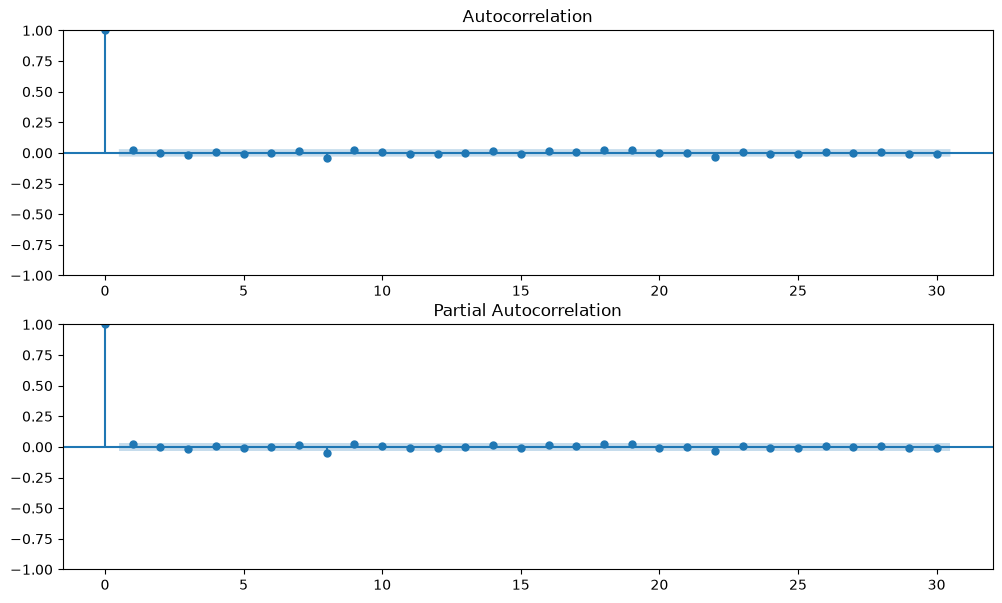


Ljung-Box Test: Autocorrelation (p > 0.05 is good):
      lb_stat  lb_pvalue
1    1.904813   0.167541
2    1.907209   0.385349
3    3.765184   0.287962
4    4.032343   0.401646
5    4.439383   0.488035
6    4.439419   0.617434
7    5.526432   0.595998
8   13.807917   0.086911
9   15.400949   0.080495
10  15.731154   0.107591

ARCH-LM Test statistic: 4.6273, p-value: 0.9146
(p > 0.05 → no remaining ARCH effects)
If p-value is below 0.05, the model may need higher-order GARCH terms. This suggests that there exists higher-order volatility clustering in the residuals.


In [31]:
# 1. Standardized residuals should be white noise
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Extract standardized residuals
std_resid = result.std_resid.dropna()

fig, ax = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(std_resid, lags=30, ax=ax[0])
plot_pacf(std_resid, lags=30, ax=ax[1])
plt.show()


# 2. Ljung-Box test
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(std_resid, lags=10, return_df=True)
print("\nLjung-Box Test: Autocorrelation (p > 0.05 is good):")
print(lb_test)


# 3. ARCH-LM test (no remaining ARCH effects)
from statsmodels.stats.diagnostic import het_arch
arch_test = het_arch(std_resid, nlags=10)
print(f"\nARCH-LM Test statistic: {arch_test[0]:.4f}, p-value: {arch_test[1]:.4f}")
print("(p > 0.05 → no remaining ARCH effects)")
print("If p-value is below 0.05, the model may need higher-order GARCH terms. This suggests that there exists higher-order volatility clustering in the residuals.")


**Diagnostics of the GARCH standardized residuals:**
- ACF / PACF: almost all bars inside the band (only small spikes at lags 8 and 22).
- Ljung-Box: p > 0.05 for all lags 1–10 (lowest 0.08) – no autocorrelation.
- ARCH-LM: p = 0.9146 – no ARCH effects left.

GARCH fixed the problems from the ARIMA diagnostics. The model is OK for forecasting.

# Step 10: Forecast

    Day  Forecasted_Price  Volatility  Upper_1sigma  Lower_1sigma  \
0     1        333.462914    5.148223    338.611137    328.314691   
1     2        333.906428    7.319002    341.225430    326.587426   
2     3        334.350532    9.010079    343.360611    325.340452   
3     4        334.795226   10.456409    345.251635    324.338817   
4     5        335.240512   11.748363    346.988875    323.492149   
5     6        335.686390   12.931967    348.618357    322.754423   
6     7        336.132861   14.034372    350.167234    322.098489   
7     8        336.579926   15.073145    351.653071    321.506781   
8     9        337.027586   16.060400    353.087986    320.967186   
9    10        337.475841   17.004897    354.480738    320.470944   
10   11        337.924692   17.913202    355.837894    320.011491   
11   12        338.374140   18.790380    357.164521    319.583760   
12   13        338.824186   19.640435    358.464621    319.183752   
13   14        339.274831   20.466

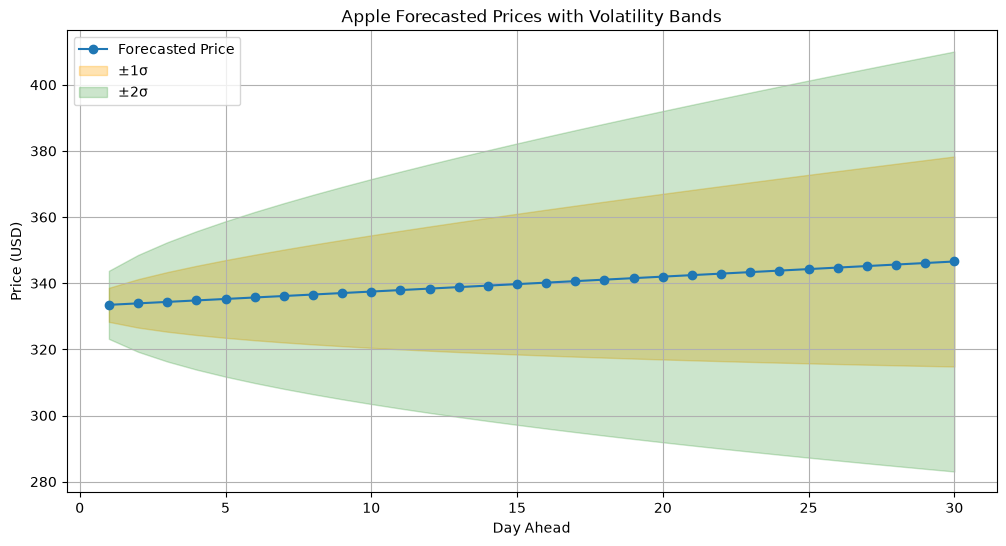

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Forecast horizon
horizon = 30  # next 30 days

# Forecast using fitted GARCH model
forecast = result.forecast(horizon=horizon)

# Extract mean forecast (returns) and conditional volatility
mean_forecast = forecast.mean.values[-1, :]  # predicted daily changes
vol_forecast = np.sqrt(np.cumsum(forecast.variance.values[-1, :]))  # conditional std dev

# Reconstruct forecasted prices from last known closing price
last_price = df['Close'].iloc[-1]
price_forecast = [last_price]
for r in mean_forecast:
    price_forecast.append(price_forecast[-1] * np.exp(r / 100))

price_forecast = price_forecast[1:]  # remove initial last price

# Create DataFrame
forecast_df = pd.DataFrame({
    'Day': range(1, horizon+1),
    'Forecasted_Price': price_forecast,
    'Volatility': vol_forecast
})

forecast_df['Volatility'] = forecast_df['Forecasted_Price'] * forecast_df['Volatility'] / 100

# Compute 1-sigma and 2-sigma bands
forecast_df['Upper_1sigma'] = forecast_df['Forecasted_Price'] + forecast_df['Volatility']
forecast_df['Lower_1sigma'] = forecast_df['Forecasted_Price'] - forecast_df['Volatility']
forecast_df['Upper_2sigma'] = forecast_df['Forecasted_Price'] + 2*forecast_df['Volatility']
forecast_df['Lower_2sigma'] = forecast_df['Forecasted_Price'] - 2*forecast_df['Volatility']

# Display forecast table
print(forecast_df)

# Plot forecast with volatility bands
plt.figure(figsize=(12,6))
plt.plot(forecast_df['Day'], forecast_df['Forecasted_Price'], marker='o', label='Forecasted Price')
plt.fill_between(forecast_df['Day'], forecast_df['Lower_1sigma'], forecast_df['Upper_1sigma'], color='orange', alpha=0.3, label='±1σ')
plt.fill_between(forecast_df['Day'], forecast_df['Lower_2sigma'], forecast_df['Upper_2sigma'], color='green', alpha=0.2, label='±2σ')
plt.title("Apple Forecasted Prices with Volatility Bands")
plt.xlabel("Day Ahead")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


**30-day price forecast:** from 333.46 USD (day 1) to 346.57 USD (day 30). The line is almost straight because it only uses the average return (0.133% per day). The bands get wider with time because the uncertainty adds up (cumulative volatility): on day 30 the ±1σ band is 314.82 USD – 378.32 USD.

In [33]:
# Forecast next 10 days of volatility
forecasts = result.forecast(horizon=10)

# Extract volatility forecasts
volatility_forecast = np.sqrt(forecasts.variance.values[-1, :])

print("Forecasted Daily Volatility (%):")
for i, vol in enumerate(volatility_forecast, 1):
    print(f"Day {i}: {vol:.2f}%")

Forecasted Daily Volatility (%):
Day 1: 1.54%
Day 2: 1.56%
Day 3: 1.57%
Day 4: 1.58%
Day 5: 1.59%
Day 6: 1.60%
Day 7: 1.61%
Day 8: 1.62%
Day 9: 1.63%
Day 10: 1.64%


**Volatility forecast:** 1.54% tomorrow, slowly rising to 1.64% on day 10. It goes up because today's volatility is below the long-run level, about 1.89% per day (√(omega / (1 − alpha − beta))).

In [34]:
import scipy.stats as stats

# 95% VaR for tomorrow
current_price = df['Close'].iloc[-1]
tomorrow_vol = np.sqrt(forecasts.variance.values[-1, 0])

# Student-t quantile (not normal!)
t_quantile = stats.t.ppf(0.05, df=result.params['nu']) * np.sqrt((result.params['nu'] - 2) / result.params['nu'])
VaR_95 = current_price * (tomorrow_vol / 100) * t_quantile

print(f"\nCurrent Apple Price: ${current_price:.2f}")
print(f"Tomorrow's Volatility: {tomorrow_vol:.2f}%")
print(f"95% VaR: ${abs(VaR_95):.2f}")
print(f"Maximum expected loss (95% confidence): {abs(VaR_95)/current_price*100:.2f}%")


Current Apple Price: $333.02
Tomorrow's Volatility: 1.54%
95% VaR: $7.91
Maximum expected loss (95% confidence): 2.37%


**95% 1-day VaR (one share):** 7.91 USD, i.e. 2.37% of the price. With 95% confidence the loss tomorrow should not be bigger than this. The t-value is rescaled so it matches the variance used by GARCH.

In [35]:
# Risk-adjusted position sizing
account_value = 100000  # $100k account
max_risk_per_trade = 0.02  # 2% max risk

# Use forecasted volatility
next_day_vol = np.sqrt(forecasts.variance.values[-1, 0])

# Position size to risk 2% at 1 standard deviation
position_size = (account_value * max_risk_per_trade) / (current_price * next_day_vol / 100)

print(f"\nSuggested position size: {position_size:.0f} shares")
print(f"Total investment: ${position_size * current_price:,.2f}")


Suggested position size: 389 shares
Total investment: $129,544.85


**Position sizing:** to risk 2% of 100k USD (2,000 USD) on a 1σ move we could buy 389 shares. This costs 129,544.85 USD – more than the account. The formula only looks at risk, not at the cash, so in practice the position would need leverage or should be limited to 100k USD.

# Step 12: Simpler model with no any ARCH and GARCH

# DF_CLose

                               SARIMAX Results                                
Dep. Variable:             Close_diff   No. Observations:                 4087
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -8879.191
Date:                Sun, 04 Oct 2026   AIC                          17764.381
Time:                        20:56:45   BIC                          17783.328
Sample:                             0   HQIC                         17771.090
                               - 4087                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0796      0.035      2.305      0.021       0.012       0.147
ar.L1          0.0248      0.007      3.729      0.000       0.012       0.038
sigma2         4.5142      0.030    150.127      0.0

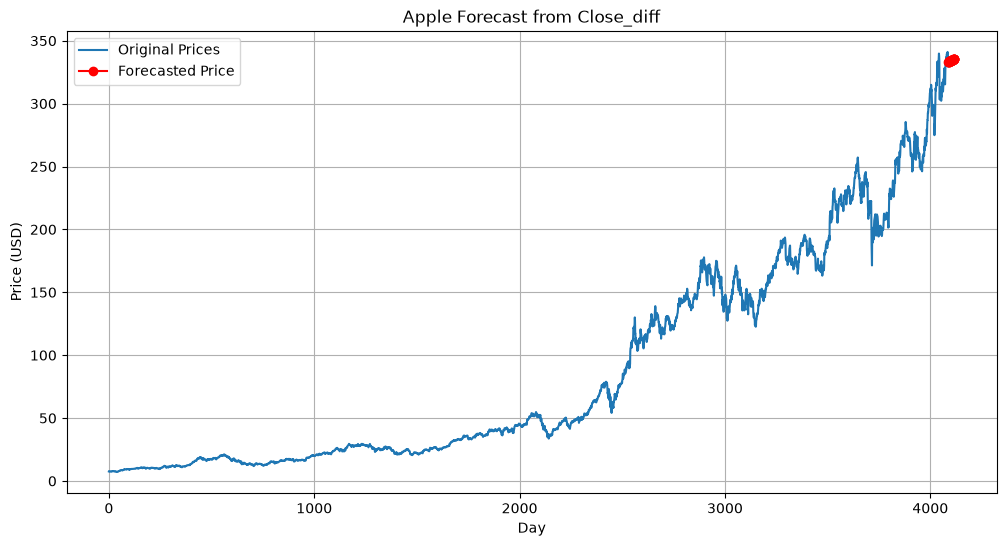


Current Apple Price: $333.02
Estimated residual volatility: $2.1249
95% VaR (simplified, teaching): $4.53


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import scipy.stats as stats

# =========================
# 1. Fit ARIMA(1,0,0) on Close_diff
# =========================
ts = df['Close_diff'].dropna().reset_index(drop=True)

model = ARIMA(ts, order=(1,0,0))
result = model.fit()

print(result.summary())

# =========================
# 2. Residual diagnostics
# =========================
resid = result.resid
std_resid = resid / resid.std()

# Ljung-Box test
lb_test = acorr_ljungbox(std_resid, lags=10, return_df=True)

print("\nLjung-Box Test (p > 0.05 → no significant autocorrelation):")
print(lb_test)

# ARCH-LM test
arch_test = het_arch(resid, nlags=10)

print(f"\nARCH-LM Test statistic: {arch_test[0]:.4f}")
print(f"ARCH-LM p-value: {arch_test[1]:.4f}")
print("(p > 0.05 → no significant ARCH effects)")

# =========================
# 3. Forecast next 30 days
# =========================
horizon = 30

forecast = result.get_forecast(steps=horizon)
mean_forecast = forecast.predicted_mean.values

# Reconstruct forecasted prices
last_price = df['Close'].iloc[-1]

price_forecast = [last_price]

for change in mean_forecast:
    price_forecast.append(price_forecast[-1] + change)

price_forecast = price_forecast[1:]

# Forecast DataFrame
forecast_df = pd.DataFrame({
    'Day': range(1, horizon + 1),
    'Forecasted_Price': price_forecast
})

print("\n30-Day Forecast:")
print(forecast_df)

# =========================
# 4. Plot forecast
# =========================
plt.figure(figsize=(12,6))

plt.plot(
    df['Close'].values,
    label='Original Prices'
)

plt.plot(
    range(len(df['Close']), len(df['Close']) + horizon),
    price_forecast,
    marker='o',
    color='red',
    label='Forecasted Price'
)

plt.title("Apple Forecast from Close_diff")
plt.xlabel("Day")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# 5. Simplified VaR
# =========================
current_price = df['Close'].iloc[-1]

# Residual standard deviation in USD
resid_vol = resid.std()

# Student-t quantile
t_quantile = stats.t.ppf(0.05, df=4)

# Simplified 95% VaR
VaR_95 = current_price * (resid_vol / current_price) * t_quantile

print(f"\nCurrent Apple Price: ${current_price:.2f}")
print(f"Estimated residual volatility: ${resid_vol:.4f}")
print(f"95% VaR (simplified, teaching): ${abs(VaR_95):.2f}")

**Simple ARIMA(1,0,0) on the differences, without GARCH:**
- Diagnostics are the same as before: autocorrelation from lag 3 and strong ARCH effects (p = 0.0000), so this model is weaker than GARCH.
- Forecast: the price rises slowly from 333.19 USD to 335.50 USD in 30 days (drift about +0.08 USD per day).
- The simplified VaR (4.53 USD) is much lower than the GARCH VaR (7.91 USD). It uses one residual std (2.12 USD) for the whole 2010–2026 period, when prices were much lower, so it underestimates today's risk.

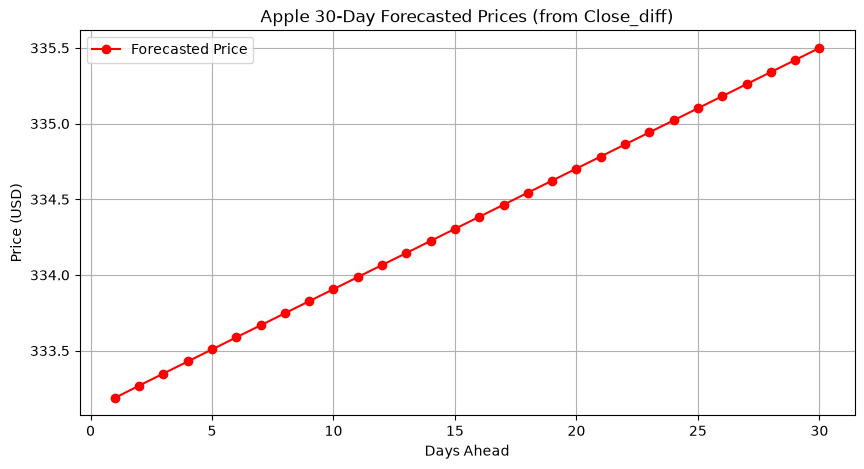

In [37]:
import matplotlib.pyplot as plt

# Separate 30-day forecast plot
plt.figure(figsize=(10,5))
plt.plot(forecast_df['Day'], forecast_df['Forecasted_Price'], marker='o', linestyle='-', color='red', label='Forecasted Price')
plt.title("Apple 30-Day Forecasted Prices (from Close_diff)")
plt.xlabel("Days Ahead")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.show()


# Now Lets Move to Machine Learning Model

In [38]:
df

,Date,Close,MA30,MA90,Close_diff
0,2010-06-30 04:00:00+00:00,7.523169,NaN,NaN,NaN
1,2010-07-01 04:00:00+00:00,7.431944,NaN,NaN,-0.091225
2,2010-07-02 04:00:00+00:00,7.385883,NaN,NaN,-0.046061
3,2010-07-06 04:00:00+00:00,7.436431,NaN,NaN,0.050548
4,2010-07-07 04:00:00+00:00,7.736725,NaN,NaN,0.300294
...,...,...,...,...,...
4083,2026-09-24 04:00:00+00:00,335.920013,321.980332,313.121842,-1.099976
4084,2026-09-25 04:00:00+00:00,341.070007,323.173999,313.605027,5.149994
4085,2026-09-28 04:00:00+00:00,338.399994,324.256332,314.046001,-2.670013
4086,2026-09-29 04:00:00+00:00,329.399994,325.049999,314.350561,-9.000000


Train size: 4005, Test size: 82

BASELINE 1: STATIC FORECAST


RMSE: $5.85
MAE:  $4.22
MAPE: 100.45%

BASELINE 2: ROLLING FORECAST


Progress: 10/82 forecasts completed


Progress: 20/82 forecasts completed


Progress: 30/82 forecasts completed


Progress: 40/82 forecasts completed


Progress: 50/82 forecasts completed


Progress: 60/82 forecasts completed


Progress: 70/82 forecasts completed


Progress: 80/82 forecasts completed

RMSE: $5.85
MAE:  $4.21
MAPE: 101.39%

BASELINE 3: NAIVE FORECAST
RMSE: $7.81
MAE:  $6.09
MAPE: 271.00%

BASELINE COMPARISON
             Model     RMSE      MAE   MAPE (%)
Naive (Last Value) 7.807471 6.093023 271.000562
      ARIMA Static 5.851927 4.216975 100.446473
     ARIMA Rolling 5.847858 4.212466 101.392246


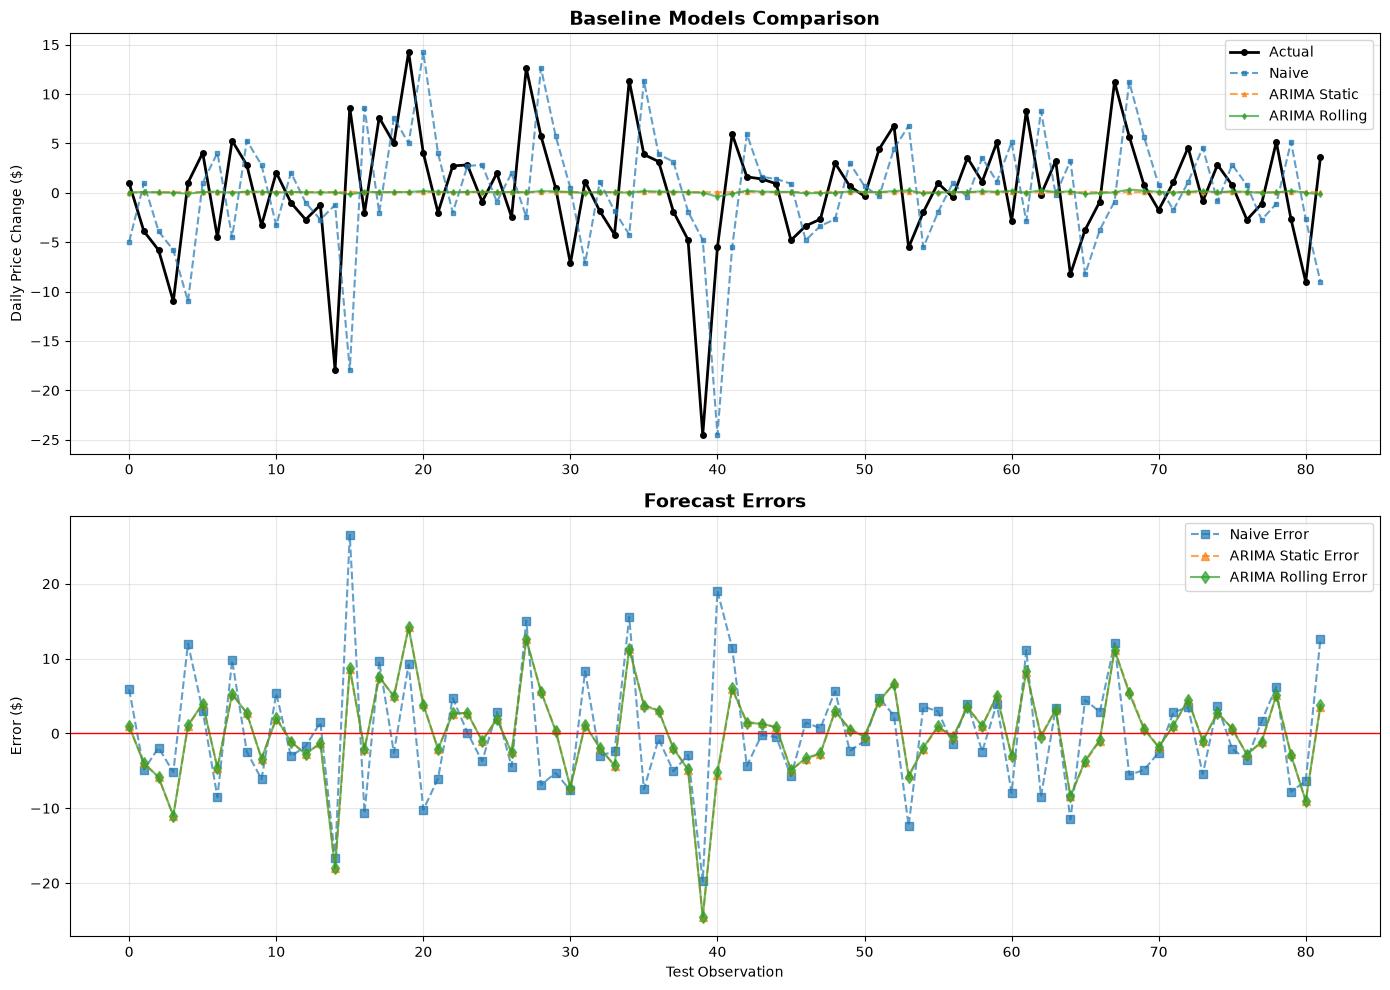


BASELINE RESULTS SAVED!


In [39]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# ===============================
# PREPARE DATA
# ===============================
series = df['Close_diff'].dropna().reset_index(drop=True)

# Train-test split (98/2)
train_size = int(len(series) * 0.98)

train = series.iloc[:train_size].reset_index(drop=True)
test = series.iloc[train_size:].reset_index(drop=True)

print(f"Train size: {len(train)}, Test size: {len(test)}")

# ===============================
# HELPER FUNCTIONS
# ===============================
def calculate_metrics(actual, pred):
    actual = np.asarray(actual)
    pred = np.asarray(pred)

    mask = np.isfinite(actual) & np.isfinite(pred)

    actual = actual[mask]
    pred = pred[mask]

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)

    # Avoid division by zero for MAPE
    nonzero = actual != 0
    mape = np.mean(
        np.abs((actual[nonzero] - pred[nonzero]) / actual[nonzero])
    ) * 100

    return rmse, mae, mape


# ===============================
# BASELINE 1: STATIC ARIMA
# ===============================
print("\n" + "="*70)
print("BASELINE 1: STATIC FORECAST")
print("="*70)

# Close_diff is already differenced
model_static = ARIMA(train, order=(1,0,0))
result_static = model_static.fit()

forecast_static = result_static.forecast(steps=len(test))

pred_static = np.asarray(forecast_static)

rmse_static, mae_static, mape_static = calculate_metrics(
    test, pred_static
)

print(f"RMSE: ${rmse_static:.2f}")
print(f"MAE:  ${mae_static:.2f}")
print(f"MAPE: {mape_static:.2f}%")


# ===============================
# BASELINE 2: ROLLING ARIMA
# ===============================
print("\n" + "="*70)
print("BASELINE 2: ROLLING FORECAST")
print("="*70)

predictions_rolling = []

history = train.tolist()

for t in range(len(test)):

    model_rolling = ARIMA(
        history,
        order=(1,0,0)
    )

    result_rolling = model_rolling.fit()

    forecast = result_rolling.forecast(steps=1)[0]

    predictions_rolling.append(forecast)

    # Add actual observation to history
    history.append(test.iloc[t])

    if (t + 1) % 10 == 0:
        print(
            f"Progress: {t+1}/{len(test)} forecasts completed"
        )

pred_rolling = np.asarray(predictions_rolling)

rmse_rolling, mae_rolling, mape_rolling = calculate_metrics(
    test, pred_rolling
)

print(f"\nRMSE: ${rmse_rolling:.2f}")
print(f"MAE:  ${mae_rolling:.2f}")
print(f"MAPE: {mape_rolling:.2f}%")


# ===============================
# BASELINE 3: NAIVE FORECAST
# ===============================
print("\n" + "="*70)
print("BASELINE 3: NAIVE FORECAST")
print("="*70)

# For Close_diff, naive forecast = previous observed difference
pred_naive = np.empty(len(test))

pred_naive[0] = train.iloc[-1]

if len(test) > 1:
    pred_naive[1:] = test.iloc[:-1].values

rmse_naive, mae_naive, mape_naive = calculate_metrics(
    test, pred_naive
)

print(f"RMSE: ${rmse_naive:.2f}")
print(f"MAE:  ${mae_naive:.2f}")
print(f"MAPE: {mape_naive:.2f}%")


# ===============================
# COMPARISON TABLE
# ===============================
print("\n" + "="*70)
print("BASELINE COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': [
        'Naive (Last Value)',
        'ARIMA Static',
        'ARIMA Rolling'
    ],
    'RMSE': [
        rmse_naive,
        rmse_static,
        rmse_rolling
    ],
    'MAE': [
        mae_naive,
        mae_static,
        mae_rolling
    ],
    'MAPE (%)': [
        mape_naive,
        mape_static,
        mape_rolling
    ]
})

print(comparison_df.to_string(index=False))


# ===============================
# VISUALIZATION
# ===============================
test_index = np.arange(len(test))

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 10)
)

# Forecast comparison
axes[0].plot(
    test_index,
    test,
    'o-',
    linewidth=2,
    markersize=4,
    label='Actual',
    color='black'
)

axes[0].plot(
    test_index,
    pred_naive,
    's--',
    linewidth=1.5,
    markersize=3,
    label='Naive',
    alpha=0.7
)

axes[0].plot(
    test_index,
    pred_static,
    '^--',
    linewidth=1.5,
    markersize=3,
    label='ARIMA Static',
    alpha=0.7
)

axes[0].plot(
    test_index,
    pred_rolling,
    'd-',
    linewidth=1.5,
    markersize=3,
    label='ARIMA Rolling',
    alpha=0.7
)

axes[0].set_title(
    'Baseline Models Comparison',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_ylabel('Daily Price Change ($)')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)


# Forecast errors
error_naive = test.values - pred_naive
error_static = test.values - pred_static
error_rolling = test.values - pred_rolling

axes[1].plot(
    test_index,
    error_naive,
    's--',
    label='Naive Error',
    alpha=0.7
)

axes[1].plot(
    test_index,
    error_static,
    '^--',
    label='ARIMA Static Error',
    alpha=0.7
)

axes[1].plot(
    test_index,
    error_rolling,
    'd-',
    label='ARIMA Rolling Error',
    alpha=0.7
)

axes[1].axhline(
    y=0,
    color='red',
    linestyle='-',
    linewidth=1
)

axes[1].set_title(
    'Forecast Errors',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Test Observation')
axes[1].set_ylabel('Error ($)')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ===============================
# SAVE BASELINE RESULTS
# ===============================
baseline_results = {
    'naive': {
        'rmse': rmse_naive,
        'mae': mae_naive,
        'mape': mape_naive
    },
    'arima_static': {
        'rmse': rmse_static,
        'mae': mae_static,
        'mape': mape_static
    },
    'arima_rolling': {
        'rmse': rmse_rolling,
        'mae': mae_rolling,
        'mape': mape_rolling
    }
}

print("\n" + "="*70)
print("BASELINE RESULTS SAVED!")
print("="*70)

**Evaluation on the last 82 days** (4 Jun – 30 Sep 2026):

| Model | RMSE | MAE |
|---|---|---|
| Naive (last change) | 7.81 USD | 6.09 USD |
| ARIMA static | 5.85 USD | 4.22 USD |
| ARIMA rolling | 5.85 USD | 4.21 USD |

ARIMA is better than naive, but static and rolling are almost the same – AR(1) predicts nearly the average change every day. MAPE (100–271%) is not useful here, because daily changes are often close to 0 (dividing by very small numbers). In the rolling forecast the next-day price = today's price + predicted change, so its error is the same as the error of the next-day price. That is why RMSE 5.85 USD can be compared with the ML models.

**Summary:** the Apple price is non-stationary with a strong upward trend, and one difference makes it stationary (d = 1). The differences have almost no autocorrelation (AR(1) or white noise), but strong volatility clustering. GARCH(1,1) with Student-t on log returns removes the ARCH effects and leaves white-noise residuals. Forecast: slow price increase, volatility about 1.5–1.6% per day, 95% 1-day VaR 7.91 USD.